# 제주도 농산물 가격 예측 데이터 분석 (EDA)

**DACON 대회**: [제주도 특산물 가격 예측 AI 경진대회](https://dacon.io/competitions/official/236176/data)

## 팀원 및 담당 파트

| 이름 | 역할 | 담당 파트 |
|------|------|----------|
| 박효준 (조장) | 데이터 탐색 및 시각화 | EDA |
| 김대원 | 피처 설계 및 앙상블 구조 | 피처 엔지니어링 |
| 신우철 | 모델 버전 관리 및 최종 통합 | 모델링 |

## 1. 데이터 컬럼 설명

### train.csv : 학습 데이터
- `ID`: 각 거래의 고유 ID (품목_법인_지역_날짜 조합)
- `timestamp`: 거래가 이루어진 날짜
- `item`: 품목 (TG: 감귤, CR: 당근, CB: 양배추, RD: 무, BC: 브로콜리)
- `corporation`: 유통 법인 (A~F)
- `location`: 지역 (J: 제주, S: 서귀포)
- `supply(kg)`: 해당 날짜의 공급량 (kg)
- `price(원/kg)`: 해당 날짜의 단가 (원/kg) **[Target]**

### test.csv : 테스트 데이터
- `ID`: 각 거래의 고유 ID
- `timestamp`: 거래가 이루어진 날짜 (2023-03-04 ~ 2023-03-31)
- `item`: 품목
- `corporation`: 유통 법인
- `location`: 지역

### sample_submission.csv : 제출 양식
- `ID`: 각 거래의 고유 ID
- `answer`: 예측한 단가 (원/kg)
* 제출을 위한 양식
* 2023년 03월 04일부터 2023년 03월 31일까지의 price(원/kg)을 예측
* ID는 품목, 유통 법인, 지역 코드로 구성된 식별자
* 해당 ID에 맞춰 price(원/kg) 예측값을 answer 컬럼에 기입해야 함

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
warnings.filterwarnings('ignore')

# 한글 폰트
try:
    from korean_font import set_korean_font
    set_korean_font()
except:
    if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif platform.system() == 'Darwin':
        plt.rcParams['font.family'] = 'AppleGothic'
    else:
        plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

PRICE_COL  = 'price(원/kg)'
SUPPLY_COL = 'supply(kg)'
DATA_PATH  = '../data/'

train = pd.read_csv(DATA_PATH + 'train.csv')
print('라이브러리 로드 및 데이터 로드 완료')

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
라이브러리 로드 및 데이터 로드 완료


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from korean_font import set_korean_font

# 한글 폰트 설정
set_korean_font()

# 데이터 불러오기
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

print("Train Data Shape:", train.shape)
print("Test Data Shape:", test.shape)
train.head()

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
Train Data Shape: (59397, 7)
Test Data Shape: (1092, 5)


,ID,timestamp,item,corporation,location,supply(kg),price(원/kg)
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0
3,TG_A_J_20190104,2019-01-04,TG,A,J,25000.0,1408.0
4,TG_A_J_20190105,2019-01-05,TG,A,J,32352.0,1250.0


In [45]:
print("--- Train Missing Values ---")
print(train.isnull().sum())
print("\n--- Test Missing Values ---")
print(test.isnull().sum())

--- Train Missing Values ---
ID             0
timestamp      0
item           0
corporation    0
location       0
supply(kg)     0
price(원/kg)    0
dtype: int64

--- Test Missing Values ---
ID             0
timestamp      0
item           0
corporation    0
location       0
dtype: int64


In [46]:
# 1. 데이터 로드 (변수명을 train_df로 통일합니다)
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. 컬럼명 변환 (한글/단위 제거)
# train 데이터 변환
train_df.rename(columns={
    'supply(kg)': 'supply',
    'price(원/kg)': 'price'
}, inplace=True)

# 3. 날짜 데이터 형식 변환 (String -> Datetime)
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])

# 4. 날짜 파생 변수 생성 (EDA와 모델링에 모두 사용됨)
def add_date_features(df):
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['day'] = df['timestamp'].dt.day
    df['dow'] = df['timestamp'].dt.dayofweek # 0:월, 6:일
    df['day_name'] = df['timestamp'].dt.day_name()
    return df
# 가격과 물량이 0인 날짜 마킹 및 요일 추출
train_df['is_zero'] = (train_df['price'] == 0) & (train_df['supply'] == 0)
train_df['day_name'] = train_df['timestamp'].dt.day_name()

train_df = add_date_features(train_df)
test_df = add_date_features(test_df)

print("✅ 컬럼명 변환 및 날짜 피처 생성 완료!")
print(f"변환된 컬럼명: {train_df.columns.tolist()}")
display(train_df.head(3))

✅ 컬럼명 변환 및 날짜 피처 생성 완료!
변환된 컬럼명: ['ID', 'timestamp', 'item', 'corporation', 'location', 'supply', 'price', 'is_zero', 'day_name', 'year', 'month', 'day', 'dow']


,ID,timestamp,item,corporation,location,supply,price,is_zero,day_name,year,month,day,dow
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0,True,Tuesday,2019,1,1,1
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0,True,Wednesday,2019,1,2,2
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0,False,Thursday,2019,1,3,3


In [47]:

# ─── ID 컬럼 구조 분석 ───────────────────────────────────────────────
print('=== ID 컬럼 구조 분석 ===')
sample_ids = train['ID'].head(10).tolist()
for sid in sample_ids:
    parts = sid.split('_')
    print(f'  {sid}  →  품목={parts[0]}, 법인={parts[1]}, 지역={parts[2]}, 날짜={parts[3]}')

print()
print('=== ID 파싱 검증 ===')
id_parsed = train['ID'].str.split('_', expand=True)
id_parsed.columns = ['item_id', 'corp_id', 'loc_id', 'date_id']

match_item = (id_parsed['item_id'] == train['item']).all()
match_corp = (id_parsed['corp_id'] == train['corporation']).all()
match_loc  = (id_parsed['loc_id']  == train['location']).all()
print(f'  ID의 품목 부분 == item 컬럼: {match_item}')
print(f'  ID의 법인 부분 == corporation 컬럼: {match_corp}')
print(f'  ID의 지역 부분 == location 컬럼: {match_loc}')

id_date_as_ts = pd.to_datetime(id_parsed['date_id'], format='%Y%m%d')
ts_col = pd.to_datetime(train['timestamp'])
match_date = (id_date_as_ts.values == ts_col.values).all()
print(f'  ID의 날짜 부분 == timestamp 컬럼: {match_date}')

print()
print('=== item 코드 의미 ===')
item_map = {'TG': '감귤 (Tangerine)', 'BC': '브로콜리 (Broccoli)',
            'RD': '무 (Radish)', 'CR': '당근 (Carrot)', 'CB': '양배추 (Cabbage)'}
for code, name in item_map.items():
    cnt = (train['item'] == code).sum()
    pct = cnt / len(train) * 100
    print(f'  {code}: {name:25s} → {cnt:,}행 ({pct:.1f}%)')

print()
print('=== corporation 코드 (법인) ===')
corp_counts = train['corporation'].value_counts().sort_index()
for code, cnt in corp_counts.items():
    items = train[train['corporation'] == code]['item'].unique().tolist()
    print(f'  법인 {code}: {cnt:,}행 ({cnt/len(train)*100:.1f}%)  담당 품목: {items}')

print()
print('=== location 코드 (지역) ===')
loc_map = {'J': '제주시 (Jeju-si)', 'S': '서귀포시 (Seogwipo-si)'}
for code, name in loc_map.items():
    cnt = (train['location'] == code).sum()
    pct = cnt / len(train) * 100
    items = train[train['location'] == code]['item'].unique().tolist()
    print(f'  {code}: {name:28s} → {cnt:,}행 ({pct:.1f}%)  품목: {items}')


=== ID 컬럼 구조 분석 ===
  TG_A_J_20190101  →  품목=TG, 법인=A, 지역=J, 날짜=20190101
  TG_A_J_20190102  →  품목=TG, 법인=A, 지역=J, 날짜=20190102
  TG_A_J_20190103  →  품목=TG, 법인=A, 지역=J, 날짜=20190103
  TG_A_J_20190104  →  품목=TG, 법인=A, 지역=J, 날짜=20190104
  TG_A_J_20190105  →  품목=TG, 법인=A, 지역=J, 날짜=20190105
  TG_A_J_20190106  →  품목=TG, 법인=A, 지역=J, 날짜=20190106
  TG_A_J_20190107  →  품목=TG, 법인=A, 지역=J, 날짜=20190107
  TG_A_J_20190108  →  품목=TG, 법인=A, 지역=J, 날짜=20190108
  TG_A_J_20190109  →  품목=TG, 법인=A, 지역=J, 날짜=20190109
  TG_A_J_20190110  →  품목=TG, 법인=A, 지역=J, 날짜=20190110

=== ID 파싱 검증 ===
  ID의 품목 부분 == item 컬럼: True
  ID의 법인 부분 == corporation 컬럼: True
  ID의 지역 부분 == location 컬럼: True
  ID의 날짜 부분 == timestamp 컬럼: True

=== item 코드 의미 ===
  TG: 감귤 (Tangerine)            → 15,230행 (25.6%)
  BC: 브로콜리 (Broccoli)           → 13,707행 (23.1%)
  RD: 무 (Radish)                → 12,184행 (20.5%)
  CR: 당근 (Carrot)               → 10,661행 (17.9%)
  CB: 양배추 (Cabbage)             → 7,615행 (12.8%)

=== corporation 코드 (법인) ===
  

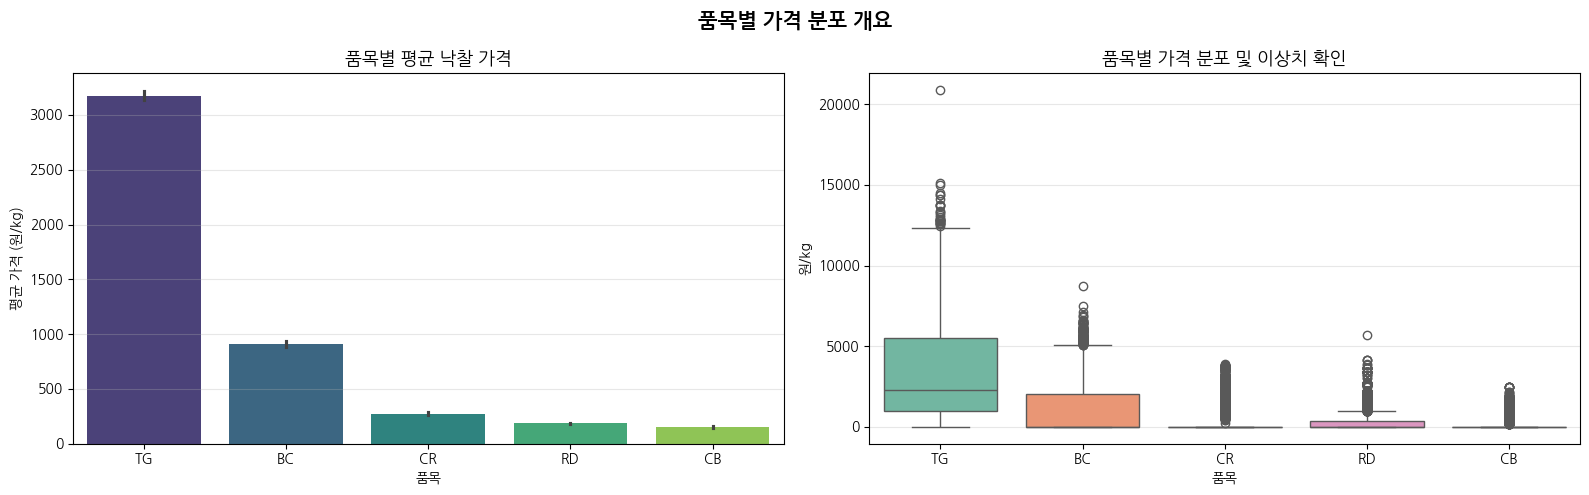


[품목별 가격 통계 — 이상치 임계값 설정 근거]
          평균     중앙값      최대값   99%ile
item                                  
BC     910.0     0.0   8750.0   5053.0
CB     152.0     0.0   2500.0   1462.0
CR     273.0     0.0   3882.0   2834.0
RD     187.0     0.0   5715.0   1613.0
TG    3177.0  2274.0  20909.0  10000.0


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (1) 품목별 평균 가격 — 막대 그래프
item_order = train.groupby('item')[PRICE_COL].mean().sort_values(ascending=False).index
sns.barplot(
    x='item', y=PRICE_COL, data=train,
    order=item_order, palette='viridis', ax=axes[0]
)
axes[0].set_title('품목별 평균 낙찰 가격', fontsize=13)
axes[0].set_xlabel('품목'); axes[0].set_ylabel('평균 가격 (원/kg)')
axes[0].grid(axis='y', alpha=0.3)

# (2) Boxplot — 분포 및 이상치
sns.boxplot(
    x='item', y=PRICE_COL, data=train,
    order=item_order, palette='Set2', ax=axes[1]
)
axes[1].set_title('품목별 가격 분포 및 이상치 확인', fontsize=13)
axes[1].set_xlabel('품목'); axes[1].set_ylabel('원/kg')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('품목별 가격 분포 개요', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_01_price_dist.png', dpi=150, bbox_inches='tight') if False else None
plt.show()

# 이상치 임계값 근거 출력
print('\n[품목별 가격 통계 — 이상치 임계값 설정 근거]')
stats = train.groupby('item')[PRICE_COL].agg(['mean','median','max', lambda x: x.quantile(0.99)])
stats.columns = ['평균','중앙값','최대값','99%ile']
print(stats.round(0))

In [49]:
# 1. timestamp 컬럼을 날짜 형식으로 변환 (이 줄이 빠져서 에러가 난 것입니다)
train['timestamp'] = pd.to_datetime(train['timestamp'])

# 2. 이제 다시 요일 추출 실행
train['day_of_week'] = train['timestamp'].dt.day_name()

# 이후 코드 진행
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
DOW_KR    = {'Monday':'월','Tuesday':'화','Wednesday':'수',
             'Thursday':'목','Friday':'금','Saturday':'토','Sunday':'일'}

print("✅ 요일 추출 성공!")

✅ 요일 추출 성공!


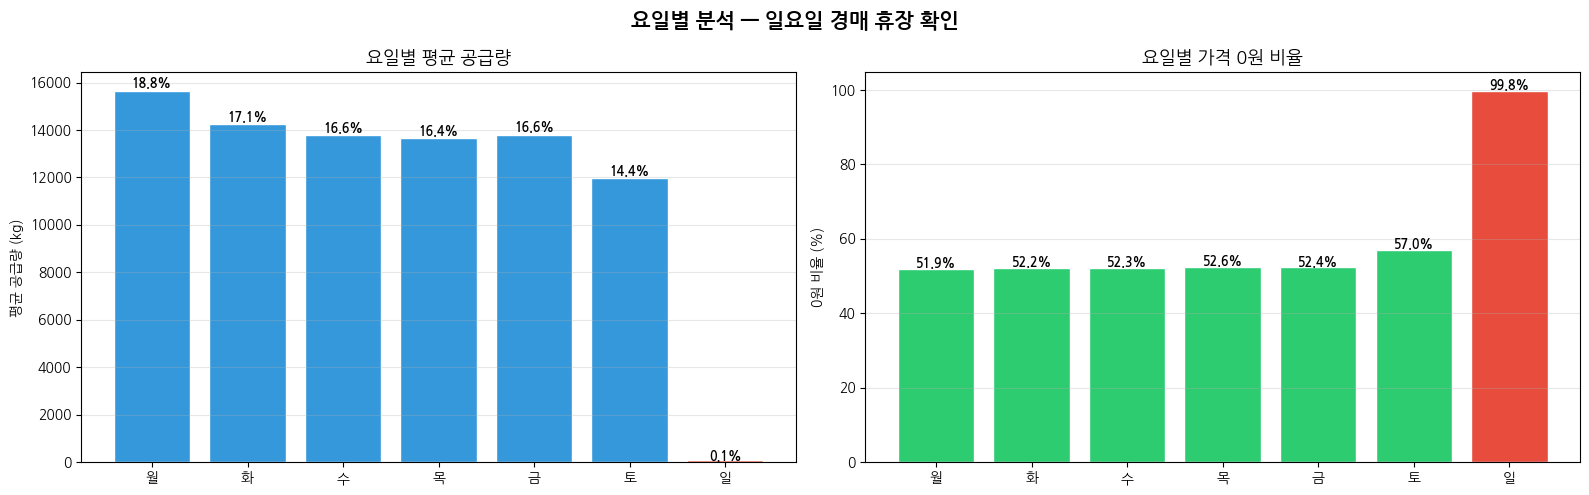


일요일 가격 0원 비율: 99.8%  →  후처리 시 일요일 예측값 0 처리 필요


In [50]:
train['day_of_week'] = train['timestamp'].dt.day_name()
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
DOW_KR    = {'Monday':'월','Tuesday':'화','Wednesday':'수',
             'Thursday':'목','Friday':'금','Saturday':'토','Sunday':'일'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (1) 요일별 평균 공급량
avg_supply = train.groupby('day_of_week')[SUPPLY_COL].mean().reindex(DOW_ORDER)
bars0 = axes[0].bar(
    [DOW_KR[d] for d in DOW_ORDER], avg_supply.values,
    color=['#e74c3c' if d == 'Sunday' else '#3498db' for d in DOW_ORDER],
    edgecolor='white'
)
for i, val in enumerate(avg_supply.values):
    pct = val / avg_supply.sum() * 100
    axes[0].text(i, val * 1.01, f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('요일별 평균 공급량', fontsize=13)
axes[0].set_ylabel('평균 공급량 (kg)'); axes[0].grid(axis='y', alpha=0.3)

# (2) 요일별 0원 비율
zero_rate = train.groupby('day_of_week')[PRICE_COL].apply(
    lambda x: (x == 0).sum() / len(x) * 100
).reindex(DOW_ORDER)
bars1 = axes[1].bar(
    [DOW_KR[d] for d in DOW_ORDER], zero_rate.values,
    color=['#e74c3c' if d == 'Sunday' else '#2ecc71' for d in DOW_ORDER],
    edgecolor='white'
)
for i, val in enumerate(zero_rate.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('요일별 가격 0원 비율', fontsize=13)
axes[1].set_ylabel('0원 비율 (%)'); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('요일별 분석 — 일요일 경매 휴장 확인', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

sun_zero = zero_rate['Sunday']
print(f'\n일요일 가격 0원 비율: {sun_zero:.1f}%  →  후처리 시 일요일 예측값 0 처리 필요')

### 계절성 분석

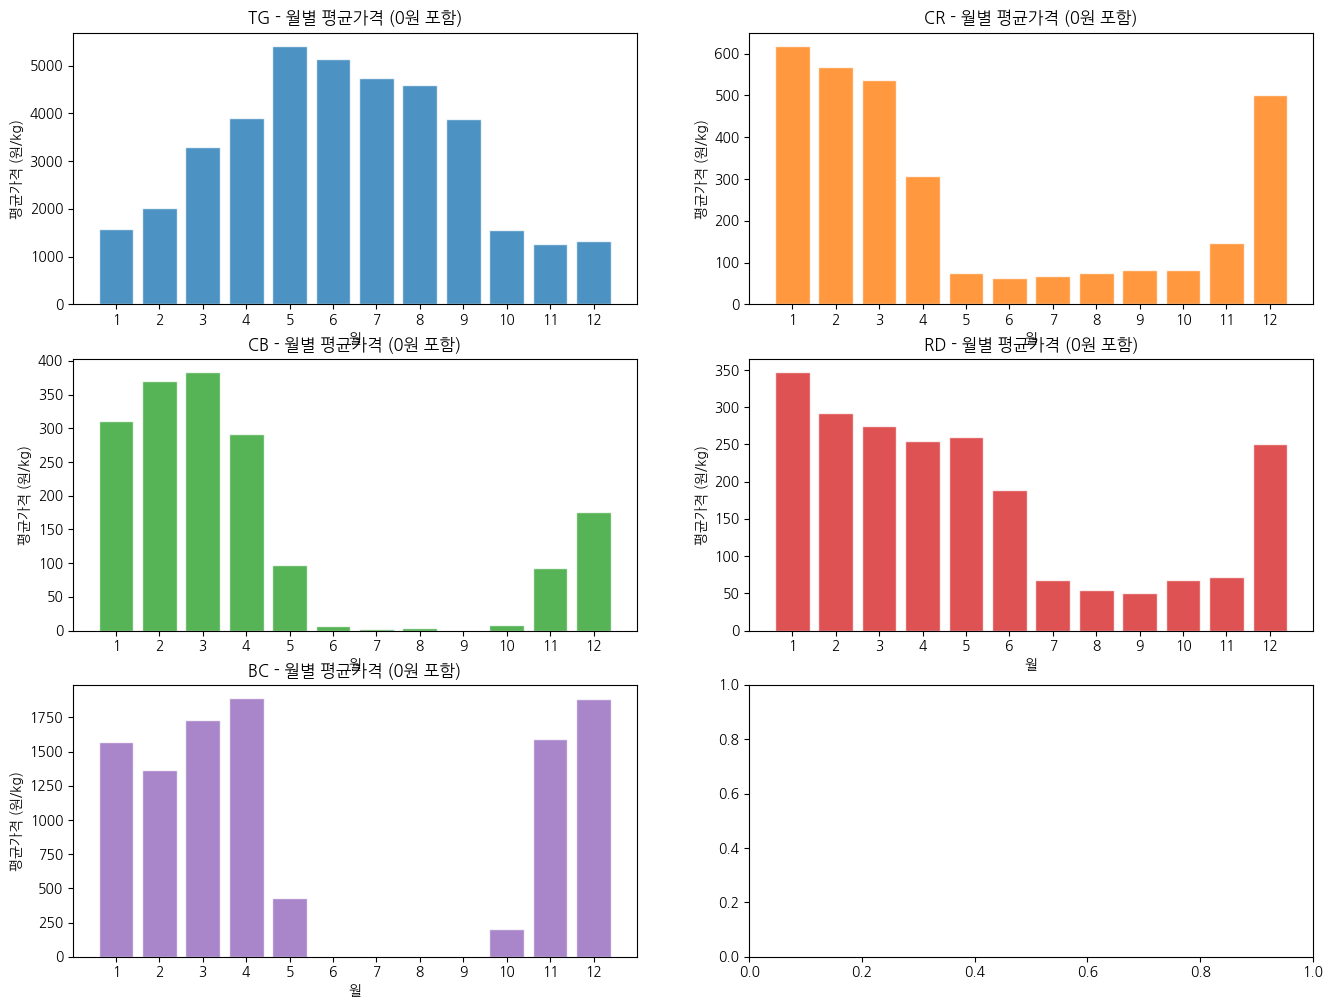

In [52]:
# 1. 전처리 확인 (month 컬럼이 없다면 생성)
if 'month' not in train_df.columns:
    train_df['month'] = train_df['timestamp'].dt.month

# 2. 변수 설정
date_col = 'timestamp'
item_col = 'item'
target_col = 'price'  # 컬럼명 확인 필요 (price 또는 price(원/kg))

# 3. 0원 데이터를 포함한 전체 데이터 사용
# (필터링 없이 train_df를 그대로 사용합니다)
train = train_df 

if date_col and target_col and 'month' in train.columns:
    month_labels = [f'{m}월' for m in range(1, 13)]

    if item_col:
        items = train[item_col].unique()
        n_items = len(items)
        cols = 2
        rows = (n_items + 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
        axes = axes.flatten()

        for i, item in enumerate(items):
            # 특정 품목의 전체 데이터(0원 포함) 추출
            df_item = train[train[item_col] == item]
            
            # 월별 평균 계산 (0원이 포함되므로 결과값이 낮아집니다)
            monthly = df_item.groupby('month')[target_col].mean()
            
            # 모든 달(1~12월)을 표시하기 위해 재색인
            monthly = monthly.reindex(range(1, 13), fill_value=0)
            
            axes[i].bar(monthly.index, monthly.values, color=f'C{i}', alpha=0.8, edgecolor='white')
            axes[i].set_title(f'{item} - 월별 평균가격 (0원 포함)', fontsize=12)
            axes[i].set_xlabel('월')
            axes[i].set_ylabel('평균가격 (원/kg)')
            axes[i].set_xticks(range(1, 13))
            axes[i].set_xticklabels

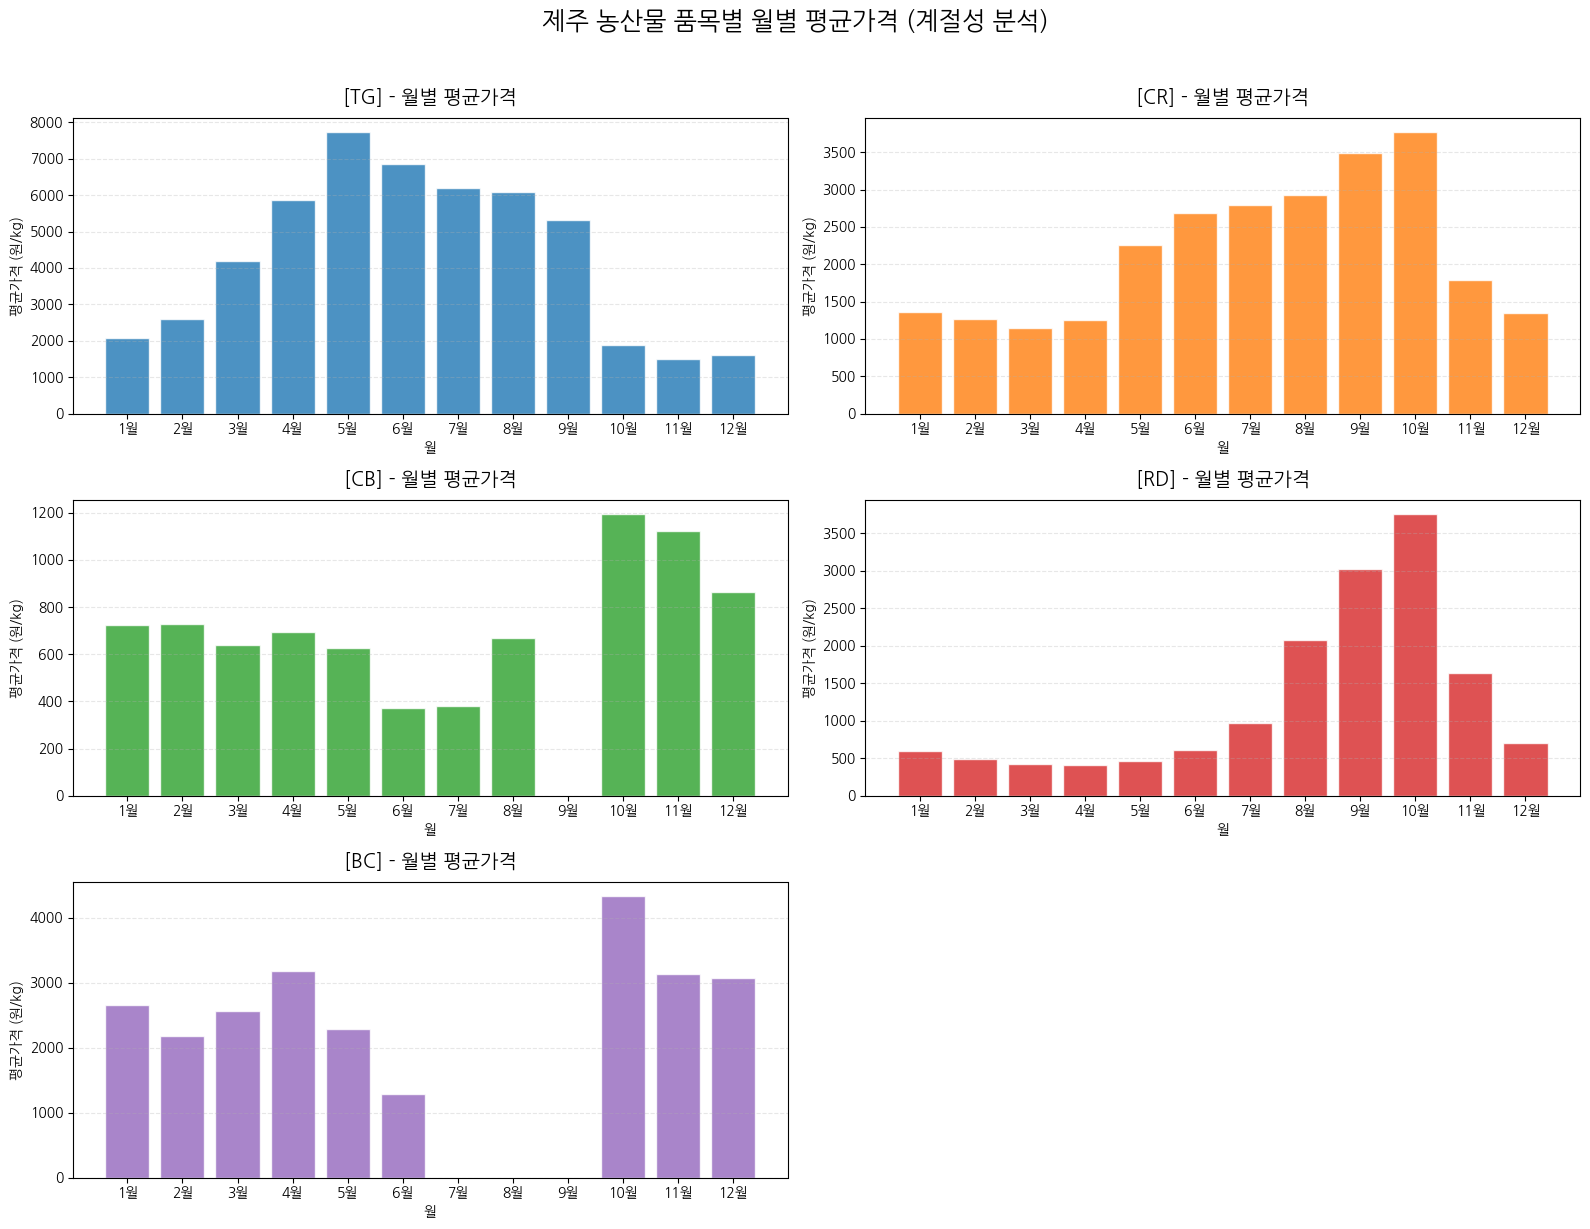

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 전처리 상태 확인 (컬럼명 및 month 생성)
if 'month' not in train_df.columns:
    train_df['month'] = train_df['timestamp'].dt.month

# 컬럼명 설정 (이전에 바꾼 이름에 맞춰 설정)
item_col = 'item'
target_col = 'price'  # 또는 'price(원/kg)'

# 2. 거래가 있는 데이터(0원 제외)만 필터링
df_plot = train_df[train_df[target_col] > 0].copy()

# 3. 시각화 설정
items = df_plot[item_col].unique()
n_items = len(items)
cols = 2
rows = (n_items + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

# 4. 품목별 반복문 실행
for i, item in enumerate(items):
    # 품목별 데이터 추출 및 월별 평균 계산
    df_item = df_plot[df_plot[item_col] == item]
    monthly = df_item.groupby('month')[target_col].mean()
    
    # 막대 그래프 그리기 (품목마다 다른 색상 적용)
    axes[i].bar(monthly.index, monthly.values, color=f'C{i}', alpha=0.8, edgecolor='white')
    
    # 그래프 디테일 설정
    axes[i].set_title(f'[{item}] - 월별 평균가격', fontsize=14, pad=10)
    axes[i].set_xlabel('월')
    axes[i].set_ylabel('평균가격 (원/kg)')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels([f'{m}월' for m in range(1, 13)], rotation=0)
    axes[i].grid(True, axis='y', alpha=0.3, linestyle='--')

# 사용하지 않는 빈 서브플롯은 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# 전체 제목 및 레이아웃 조정
plt.suptitle('제주 농산물 품목별 월별 평균가격 (계절성 분석)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### 1. 감귤: 5월에 가격이 가장 비싼 이유
감귤은 겨울이 제철인 과일입니다. 5월에 최고가를 찍는 이유는 **'공급의 공백기'**와 '생산 방식의 변화' 때문입니다.

저장량 고갈: 노지 감귤(밖에서 키우는 귤)은 보통 1~2월이면 수확이 끝나고 저장 물량으로 버팁니다. 5월이 되면 이 저장 물량이 거의 바닥나서 희소성이 극대화됩니다.

하우스 감귤의 등장: 5월부터는 시설(하우스)에서 재배한 감귤이 나오기 시작합니다. 하우스 귤은 난방비 등 생산 원가가 훨씬 높기 때문에 시장 가격 자체가 매우 높게 형성됩니다.

대체재 부족: 5월은 딸기가 끝물이고 수박이 본격적으로 나오기 전이라 국산 과일 수요가 감귤로 몰리는 경향이 있습니다.
### 2. 당근: 5월~11월 가격이 낮은 이유
제주 당근은 전국 생산량의 상당 부분을 차지하는 **'겨울 당근'**이 주력입니다.

수입 당근과의 경쟁: 제주 당근 수확은 보통 12월~4월에 집중됩니다. 5월부터는 저장된 제주 당근이 시장에 풀리는데, 이때 중국산 수입 당근이나 육지(경남 등)의 봄 당근이 대량으로 쏟아져 나오면서 제주산의 가격 경쟁력이 떨어집니다.

품질 저하 가능성: 저장 기간이 길어질수록 수분이 빠지는 등 상품성이 낮아져 가격이 낮게 책정되기도 합니다.

### 3. 양배추: 5월 급락 후 10월까지 저렴한 이유
양배추의 가격 변동은 **'재배 지역의 이동'**을 보면 명확합니다.

육지산 대량 출하: 제주 양배추는 12월~4월이 주력입니다. 5월부터는 전남, 충남 등 육지에서 재배된 '봄 양배추'와 '여름 양배추'가 쏟아져 나옵니다.

지리적 불리함: 육지산이 시장(가락시장 등)에 가깝기 때문에 물류비가 비싼 제주산은 5~10월 사이에는 아예 경쟁력을 잃고 산지 폐기를 하거나 판매를 중단(데이터상 0원 혹은 낮은 가격)하게 됩니다.

11월 상승: 육지산 수확이 끝나는 11월부터 다시 '제주 겨울 양배추'의 시즌이 돌아오며 가격이 회복됩니다.

### 4. 무: 7월~11월 가격 하락 원인
무는 기온에 매우 민감한 작물입니다.

고랭지 무의 등장: 7월부터는 강원도 등에서 재배되는 고랭지 여름 무가 대량으로 공급됩니다.

공급 과잉: 여름부터 가을까지는 육지 곳곳에서 무가 생산되기 때문에 제주산 무(주로 겨울 무)가 비집고 들어갈 틈이 적습니다.

가을무 수확기: 10~11월은 전국적으로 김장철을 앞두고 가을무가 대량 출하되는 시기라 1년 중 공급량이 가장 많아 가격이 하락 압박을 받습니다.


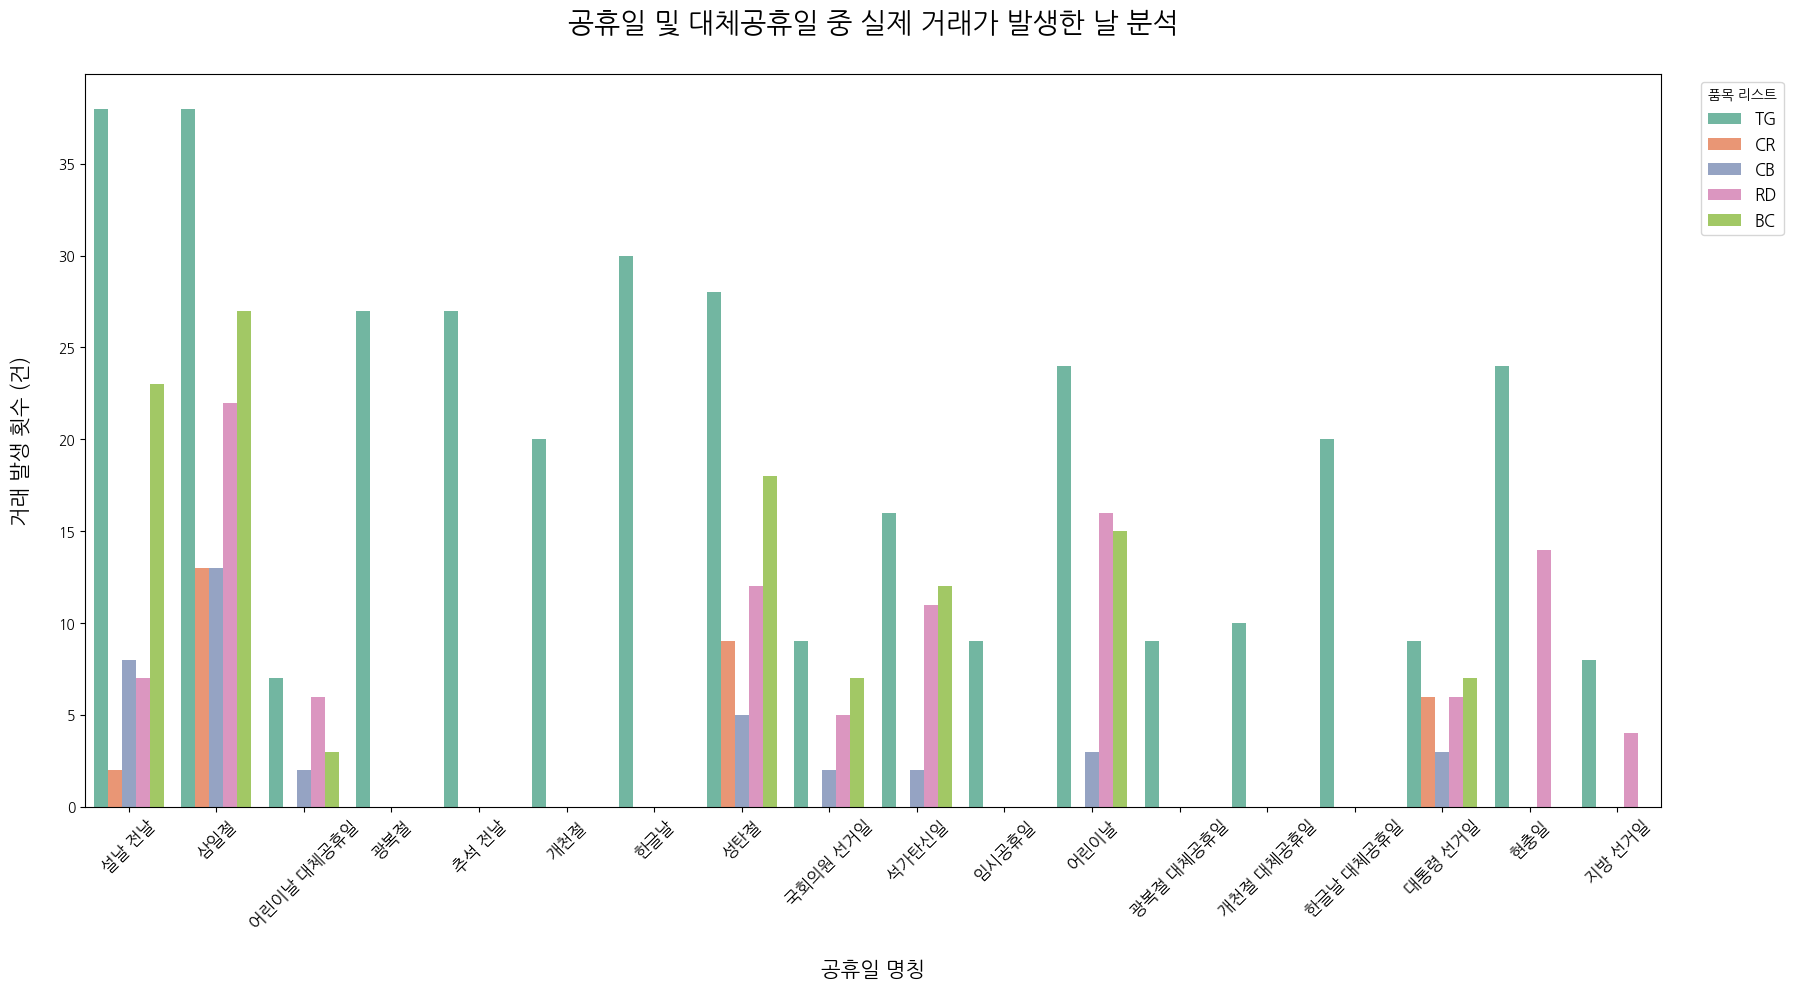

--- [공휴일 거래 상세 내역 (대체공휴일 포함)] ---


,날짜,공휴일명,품목,평균단가
0,2019-02-04,설날 전날,BC,2095.400000
1,2019-02-04,설날 전날,CB,261.500000
2,2019-02-04,설날 전날,RD,309.500000
3,2019-02-04,설날 전날,TG,2259.700000
4,2019-03-01,삼일절,BC,1997.571429
...,...,...,...,...
104,2023-03-01,삼일절,BC,3498.285714
105,2023-03-01,삼일절,CB,646.750000
106,2023-03-01,삼일절,CR,2031.750000
107,2023-03-01,삼일절,RD,585.800000


In [53]:
import pandas as pd
import holidays
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 공휴일 한글 매핑 딕셔너리 (이미지 속 영문 명칭 모두 포함)
holiday_ko = {
    # 신정
    "New Year's Day": "새해 첫날",
    "New Year's Year": "신정", 

    # 설날 (표준 및 변이형 통합)
    "Lunar New Year's Day": "설날",
    "The day preceding Lunar New Year's Day": "설날 전날",
    "The day after Lunar New Year's Day": "설날 다음날",
    "Korean New Year": "설날",
    "The day preceding Korean New Year's Day": "설날 전날",
    "The day after Korean New Year's Day": "설날 다음날",
    "The day preceding Korean New Year": "설날 전날", # 질문하신 명칭
    "The day after Korean New Year": "설날 다음날",
    "The second day of Korean New Year": "추석 셋째 날",
    
    # 삼일절 및 어린이날
    "Independence Movement Day": "삼일절",
    "Children's Day": "어린이날",
    
    # 부처님 오신 날 (표준 명칭 대응)
    "Buddha's Birthday": "석가탄신일",
    "Vesak": "석가탄신일",
    
    # 현충일, 제헌절, 광복절
    "Memorial Day": "현충일",
    "Constitution Day": "제헌절",
    "Liberation Day": "광복절",
    
    # 추석 (표준 및 변이형 통합)
    "Chuseok": "추석",
    "The day preceding Chuseok": "추석 전날",
    "The day after Chuseok": "추석 다음날",
    "The second day of Chuseok": "추석 둘째 날",
    
    # 개천절, 한글날, 성탄절
    "National Foundation Day": "개천절",
    "Hangul Day": "한글날",
    "Christmas Day": "성탄절",
    
    # 선거일 (추가)
    "National Assembly Election Day": "국회의원 선거일",
    "Presidential Election Day": "대통령 선거일",
    "Local Election Day": "지방 선거일",
    
    # 대체 공휴일 (패턴 대응)
    "Alternative holiday for Children's Day": "어린이날 대체공휴일",
    "Alternative holiday for Buddha's Birthday": "석가탄신일 대체공휴일",
    "Alternative holiday for Lunar New Year's Day": "설날 대체공휴일",
    "Alternative holiday for Korean New Year's Day": "설날 대체공휴일",
    "Alternative holiday for Chuseok": "추석 대체공휴일",
    "Alternative holiday for Independence Movement Day": "삼일절 대체공휴일",
    "Alternative holiday for Liberation Day": "광복절 대체공휴일",
    "Alternative holiday for National Foundation Day": "개천절 대체공휴일",
    "Alternative holiday for Hangul Day": "한글날 대체공휴일",
    "Alternative holiday for Constitution Day": "제헌절 대체공휴일",
    "Temporary Public Holiday": "임시공휴일", 
    "Alternative holiday for Korean New Year": "설날 대체공휴일",
}

# 2. 데이터 필터링 및 컬럼 설정
start_date = '2019-01-01'
end_date = '2023-03-03'
p_col = 'price' if 'price' in train_df.columns else 'price(원/kg)'

mask = (train_df['timestamp'] >= start_date) & (train_df['timestamp'] <= end_date)
target_df = train_df.loc[mask].copy()

# 3. 공휴일 정보 생성 및 한글화 적용
kr_holidays = holidays.KR()
target_df['is_holiday'] = target_df['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)
target_df['holiday_en'] = target_df['timestamp'].apply(lambda x: kr_holidays.get(x))
target_df['공휴일_명칭'] = target_df['holiday_en'].map(holiday_ko).fillna(target_df['holiday_en'])

# 4. 공휴일 중 실제 거래 발생 데이터 추출
sold_on_holiday = target_df[(target_df['is_holiday'] == 1) & (target_df[p_col] > 0)].copy()

# 5. 시각화 (간격 및 한글화 최적화)
if not sold_on_holiday.empty:
    plt.figure(figsize=(18, 10))
    
    # 막대 그래프 생성
    sns.countplot(data=sold_on_holiday, x='공휴일_명칭', hue='item', palette='Set2')
    
    # 텍스트 간격(pad) 및 한글화 설정
    plt.title('공휴일 및 대체공휴일 중 실제 거래가 발생한 날 분석', fontsize=20, pad=30)
    plt.xlabel('공휴일 명칭', fontsize=15, labelpad=20)
    plt.ylabel('거래 발생 횟수 (건)', fontsize=15, labelpad=20)
    
    # X축 눈금 설정 (간격을 위해 45도 회전)
    plt.xticks(rotation=45, fontsize=12)
    
    # 범례 설정 (한글화 및 위치 조정)
    plt.legend(title='품목 리스트', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
    
    plt.tight_layout()
    plt.show()

    # 결과 요약 표 출력
    summary = sold_on_holiday.groupby(['timestamp', '공휴일_명칭', 'item'])[p_col].mean().reset_index()
    summary.columns = ['날짜', '공휴일명', '품목', '평균단가']
    print("--- [공휴일 거래 상세 내역 (대체공휴일 포함)] ---")
    display(summary)

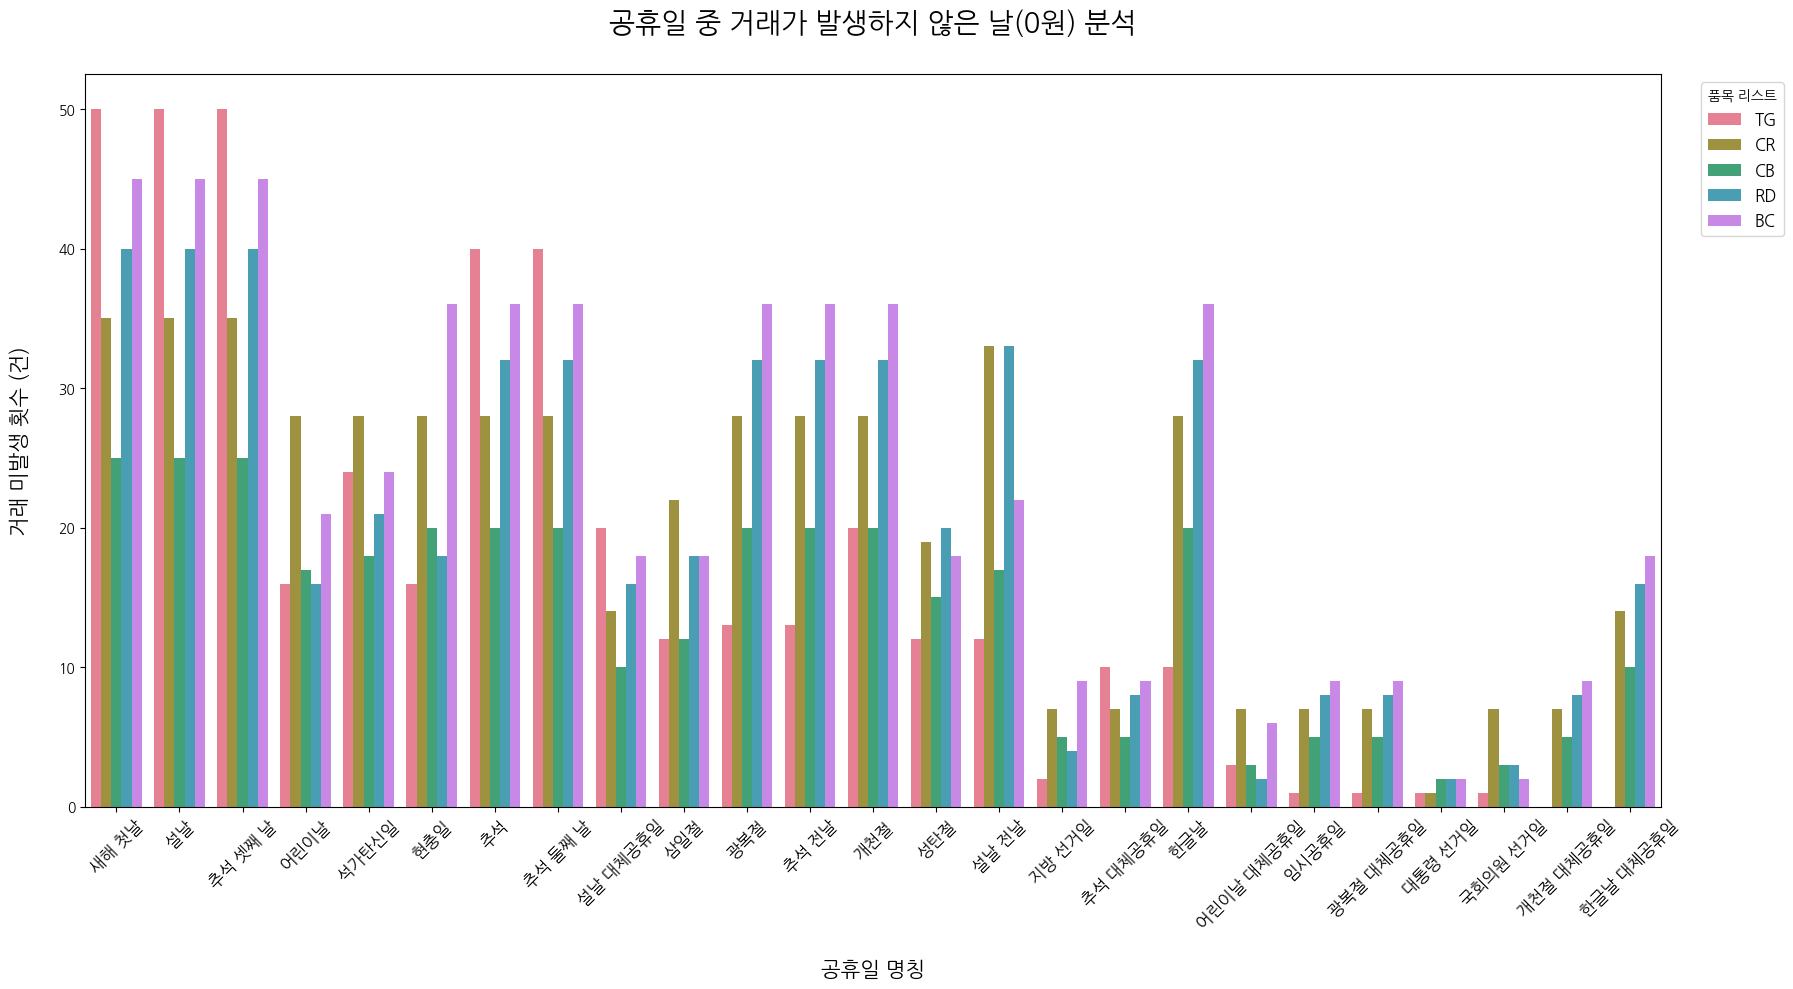

--- [거래 미발생 공휴일 상세 내역 (0원)] ---


,날짜,공휴일명,품목,데이터개수
0,2019-01-01,새해 첫날,BC,9
1,2019-01-01,새해 첫날,CB,5
2,2019-01-01,새해 첫날,CR,7
3,2019-01-01,새해 첫날,RD,8
4,2019-01-01,새해 첫날,TG,10
5,2019-02-04,설날 전날,BC,4
6,2019-02-04,설날 전날,CB,3
7,2019-02-04,설날 전날,CR,7
8,2019-02-04,설날 전날,RD,6
9,2019-02-05,설날,BC,9


In [54]:
# 4. "공휴일"이면서 "가격이 0원인(거래가 없는)" 데이터만 추출
# p_col 조건만 > 0 에서 == 0 으로 변경합니다.
no_trade_on_holiday = target_df[
    (target_df['is_holiday'] == 1) & 
    (target_df[p_col] == 0)
].copy()

# 5. 시각화 (거래 없는 공휴일 분석)
if not no_trade_on_holiday.empty:
    plt.figure(figsize=(18, 10))
    
    # 막대 그래프 생성 (거래가 없었던 횟수 카운트)
    sns.countplot(data=no_trade_on_holiday, x='공휴일_명칭', hue='item', palette='husl')
    
    plt.title('공휴일 중 거래가 발생하지 않은 날(0원) 분석', fontsize=20, pad=30)
    plt.xlabel('공휴일 명칭', fontsize=15, labelpad=20)
    plt.ylabel('거래 미발생 횟수 (건)', fontsize=15, labelpad=20)
    
    plt.xticks(rotation=45, fontsize=12)
    plt.legend(title='품목 리스트', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
    
    plt.tight_layout()
    plt.show()

    # 결과 요약 표 출력 (거래가 없었던 날짜 리스트)
    # 0원인 날의 평균을 내면 결과가 0이므로, 여기서는 날짜별 품목 리스트만 보여줍니다.
    summary_no_trade = no_trade_on_holiday.groupby(['timestamp', '공휴일_명칭', 'item']).size().reset_index()
    summary_no_trade.columns = ['날짜', '공휴일명', '품목', '데이터개수']
    print("--- [거래 미발생 공휴일 상세 내역 (0원)] ---")
    display(summary_no_trade.head(20)) # 너무 많을 수 있으니 상위 20개만 출력
else:
    print("분석 범위 내 모든 공휴일에 거래가 발생했습니다.")

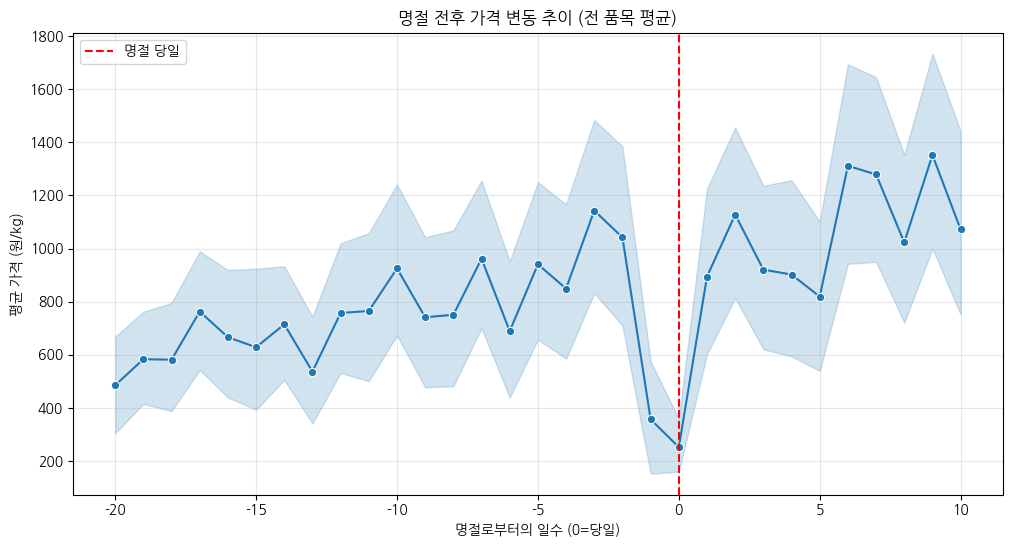

In [55]:
import holidays

kr_holidays = holidays.KR()

# 명절(설날, 추석) 날짜 추출 함수
def get_traditional_holidays(start_year, end_year):
    traditional_holidays = []
    for year in range(start_year, end_year + 1):
        for date, name in sorted(holidays.KR(years=year).items()):
            if 'Lunar New Year' in name or 'Chuseok' in name:
                traditional_holidays.append(date)
    return traditional_holidays

holiday_dates = get_traditional_holidays(2019, 2023)

def calculate_dist_to_holiday(date):
    curr_date = pd.to_datetime(date)
    diffs = [(pd.Timestamp(h) - curr_date).days for h in holiday_dates]
    min_diff = min(diffs, key=abs)
    return min_diff

train_holiday = train_df.copy()
train_holiday['dist_to_holiday'] = train_holiday['timestamp'].apply(calculate_dist_to_holiday)

plt.figure(figsize=(12, 6))
mask = (train_holiday['dist_to_holiday'] >= -20) & (train_holiday['dist_to_holiday'] <= 10)
sns.lineplot(x='dist_to_holiday', y='price', data=train_holiday[mask], marker='o')
plt.axvline(0, color='red', linestyle='--', label='명절 당일')
plt.title('명절 전후 가격 변동 추이 (전 품목 평균)')
plt.xlabel('명절로부터의 일수 (0=당일)')
plt.ylabel('평균 가격 (원/kg)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

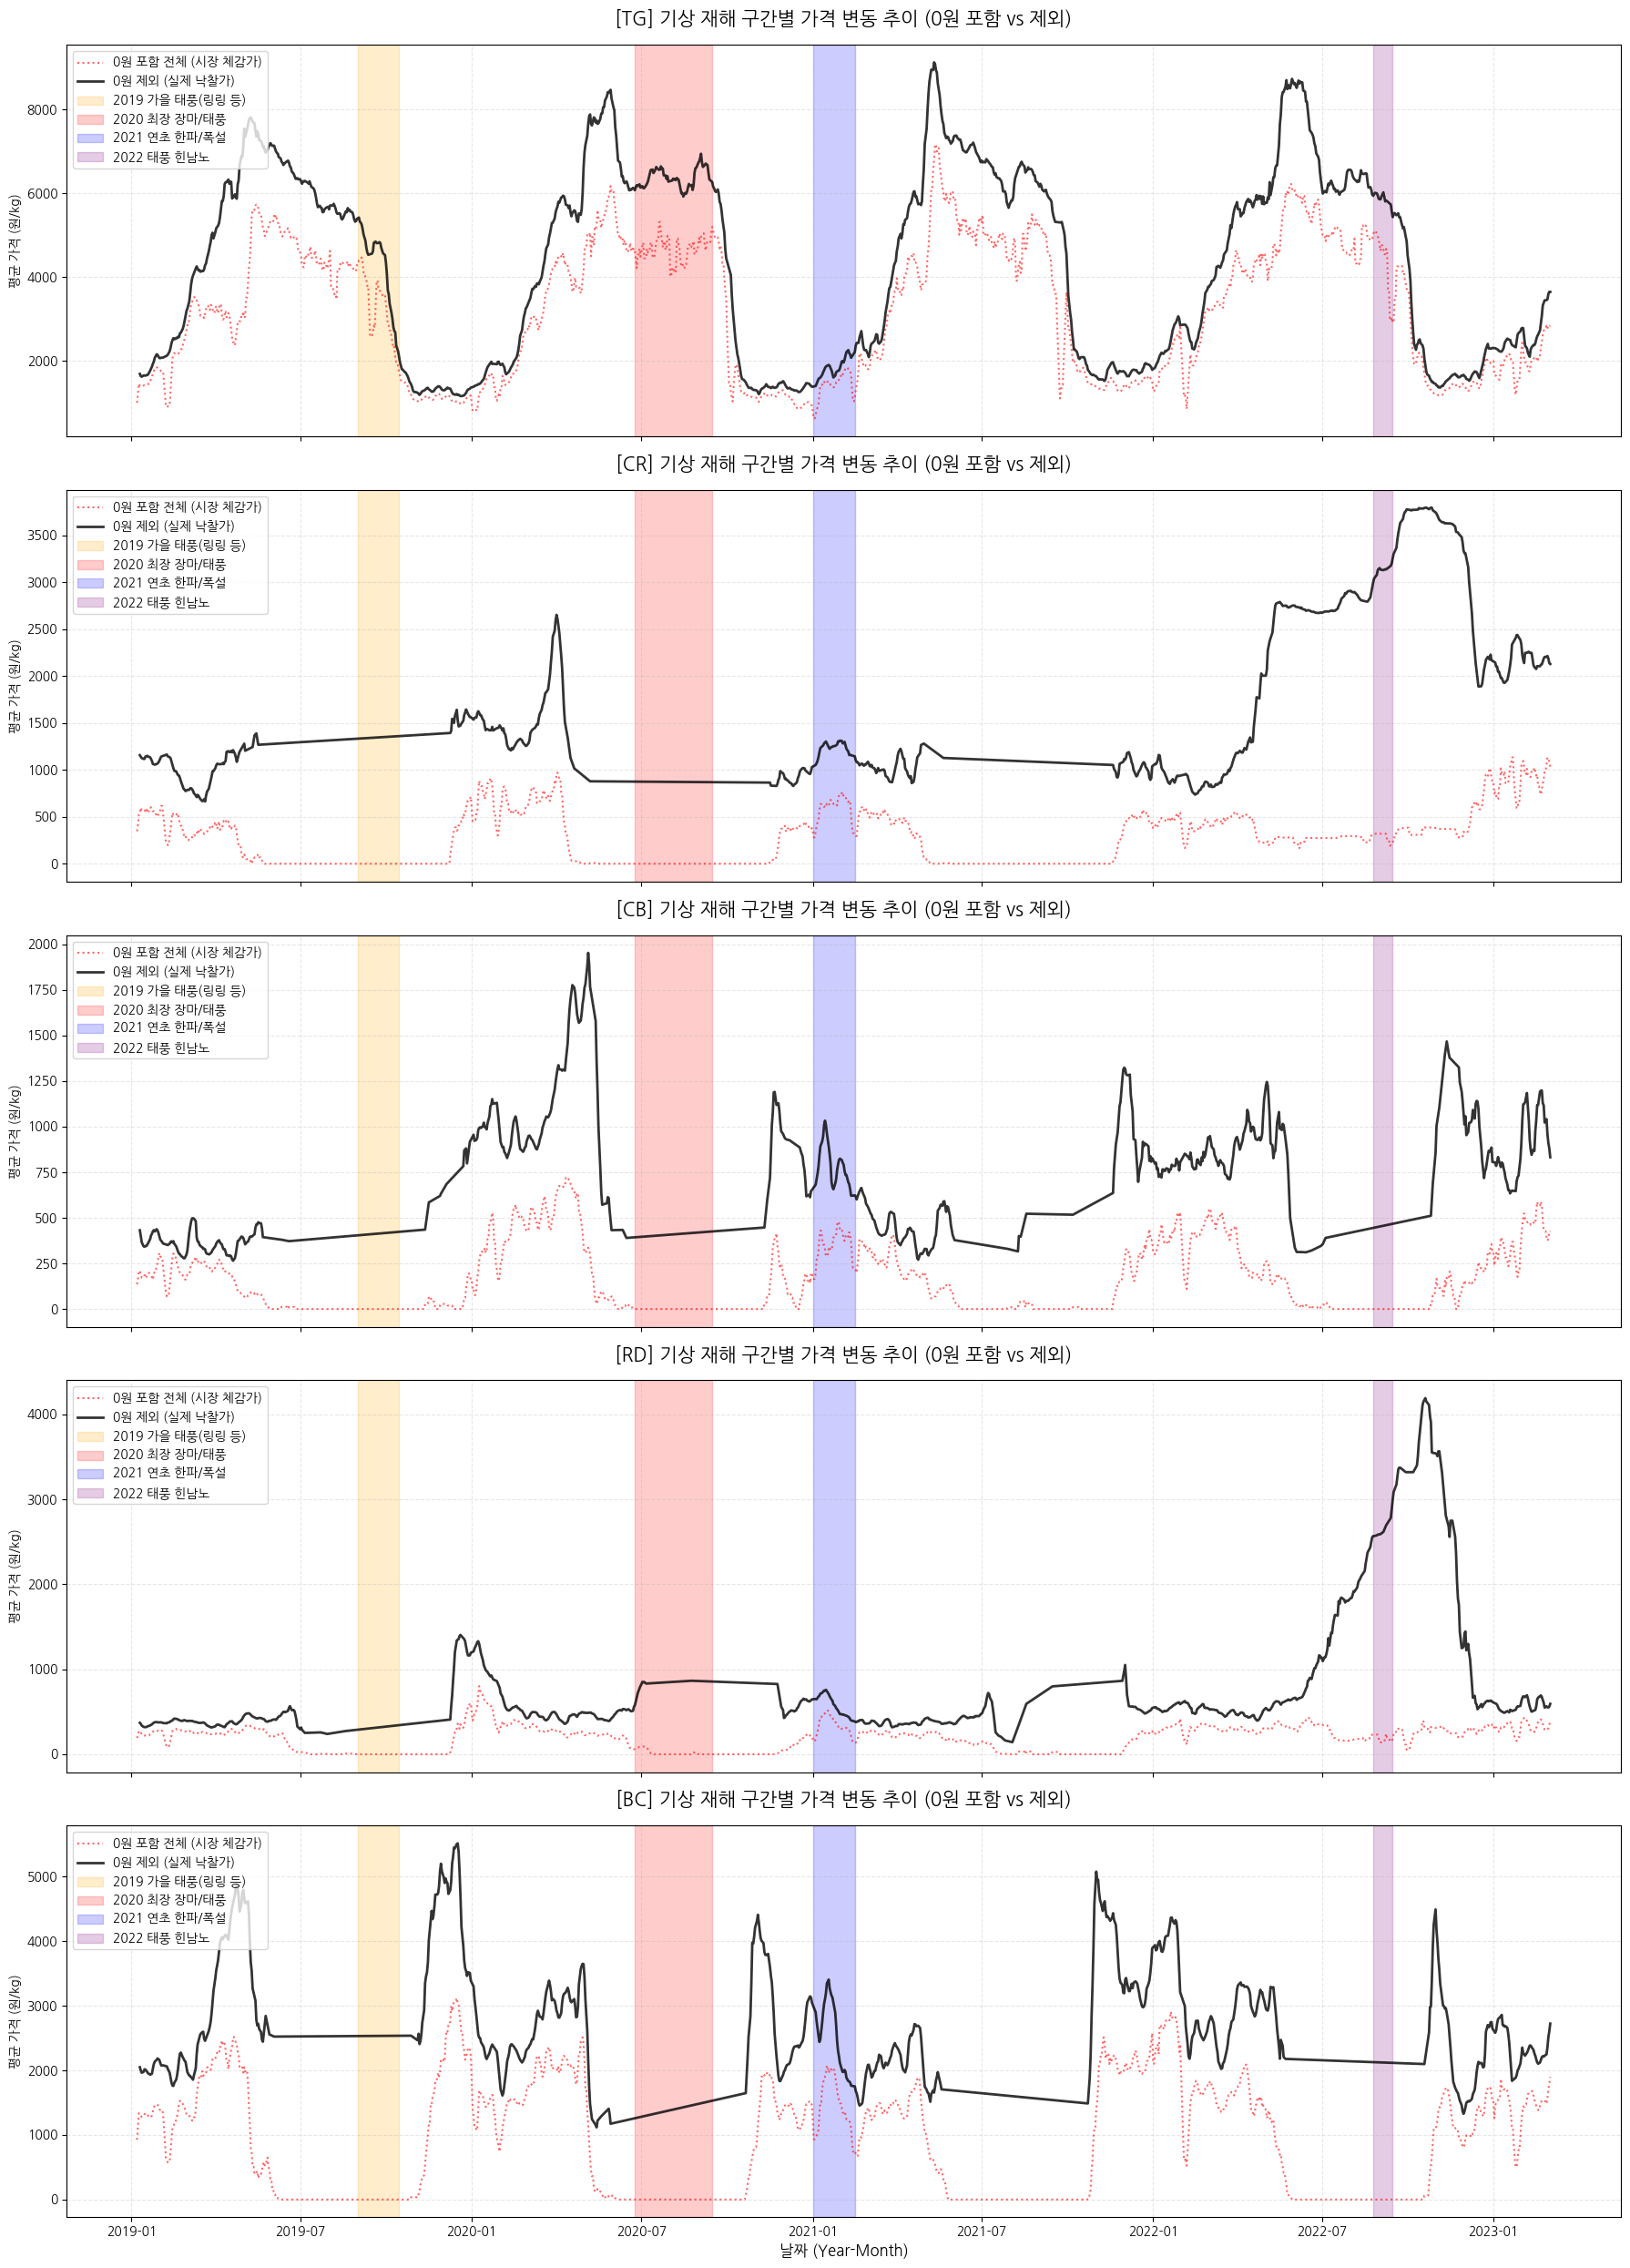

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 로드 및 날짜 설정
train = pd.read_csv('train.csv')
train['timestamp'] = pd.to_datetime(train['timestamp'])
target_col = 'price(원/kg)'  # 만약 앞에서 컬럼명을 바꿨다면 'price'로 수정하세요!

# 2. 분석에 활용할 기상 이변 기간 정의
weather_events = [
    {'name': '2019 가을 태풍(링링 등)', 'start': '2019-09-01', 'end': '2019-10-15', 'color': 'orange'},
    {'name': '2020 최장 장마/태풍', 'start': '2020-06-24', 'end': '2020-09-15', 'color': 'red'},
    {'name': '2021 연초 한파/폭설', 'start': '2021-01-01', 'end': '2021-02-15', 'color': 'blue'},
    {'name': '2022 태풍 힌남노', 'start': '2022-08-25', 'end': '2022-09-15', 'color': 'purple'}
]

# 3. 시각화 (품목별 가격 추이 + 기상 이변 구간 강조)
items = train['item'].unique()
fig, axes = plt.subplots(len(items), 1, figsize=(18, 5 * len(items)), sharex=True)

for i, item in enumerate(items):
    # -------------------------------------------------------------
    # [수정된 부분] 0원 포함 데이터와 제외 데이터를 각각 계산
    # -------------------------------------------------------------
    
    # A. 0원 포함 데이터 (빨간 점선용) - 해당 일자의 전체 평균
    df_all = train[train['item'] == item]
    daily_mean_all = df_all.groupby('timestamp')[target_col].mean()
    rolling_all = daily_mean_all.rolling(window=7).mean()
    
    # B. 0원 제외 데이터 (검은 실선용) - 실제 거래가 일어난 시세 평균
    df_real = train[(train['item'] == item) & (train[target_col] > 0)]
    daily_mean_real = df_real.groupby('timestamp')[target_col].mean()
    rolling_real = daily_mean_real.rolling(window=7).mean()
    
    # -------------------------------------------------------------
    # 그래프 그리기
    # -------------------------------------------------------------
    # 0원 포함 (시장 활성도 반영)
    axes[i].plot(rolling_all.index, rolling_all.values, label='0원 포함 전체 (시장 체감가)', 
                 color='red', alpha=0.6, linestyle=':')
    
    # 0원 제외 (순수 시세)
    axes[i].plot(rolling_real.index, rolling_real.values, label='0원 제외 (실제 낙찰가)', 
                 color='black', alpha=0.8, linewidth=2)
    
    # 기상 이변 구간 배경색(Shading) 입히기
    for event in weather_events:
        axes[i].axvspan(pd.to_datetime(event['start']), pd.to_datetime(event['end']), 
                        color=event['color'], alpha=0.2, label=event['name'])
    
    axes[i].set_title(f'[{item}] 기상 재해 구간별 가격 변동 추이 (0원 포함 vs 제외)', fontsize=15, pad=15)
    axes[i].set_ylabel('평균 가격 (원/kg)')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    
    # 중복 범례 제거 후 출력
    handles, labels = axes[i].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axes[i].legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=10)

plt.xlabel('날짜 (Year-Month)', fontsize=12)
plt.tight_layout()
plt.show()

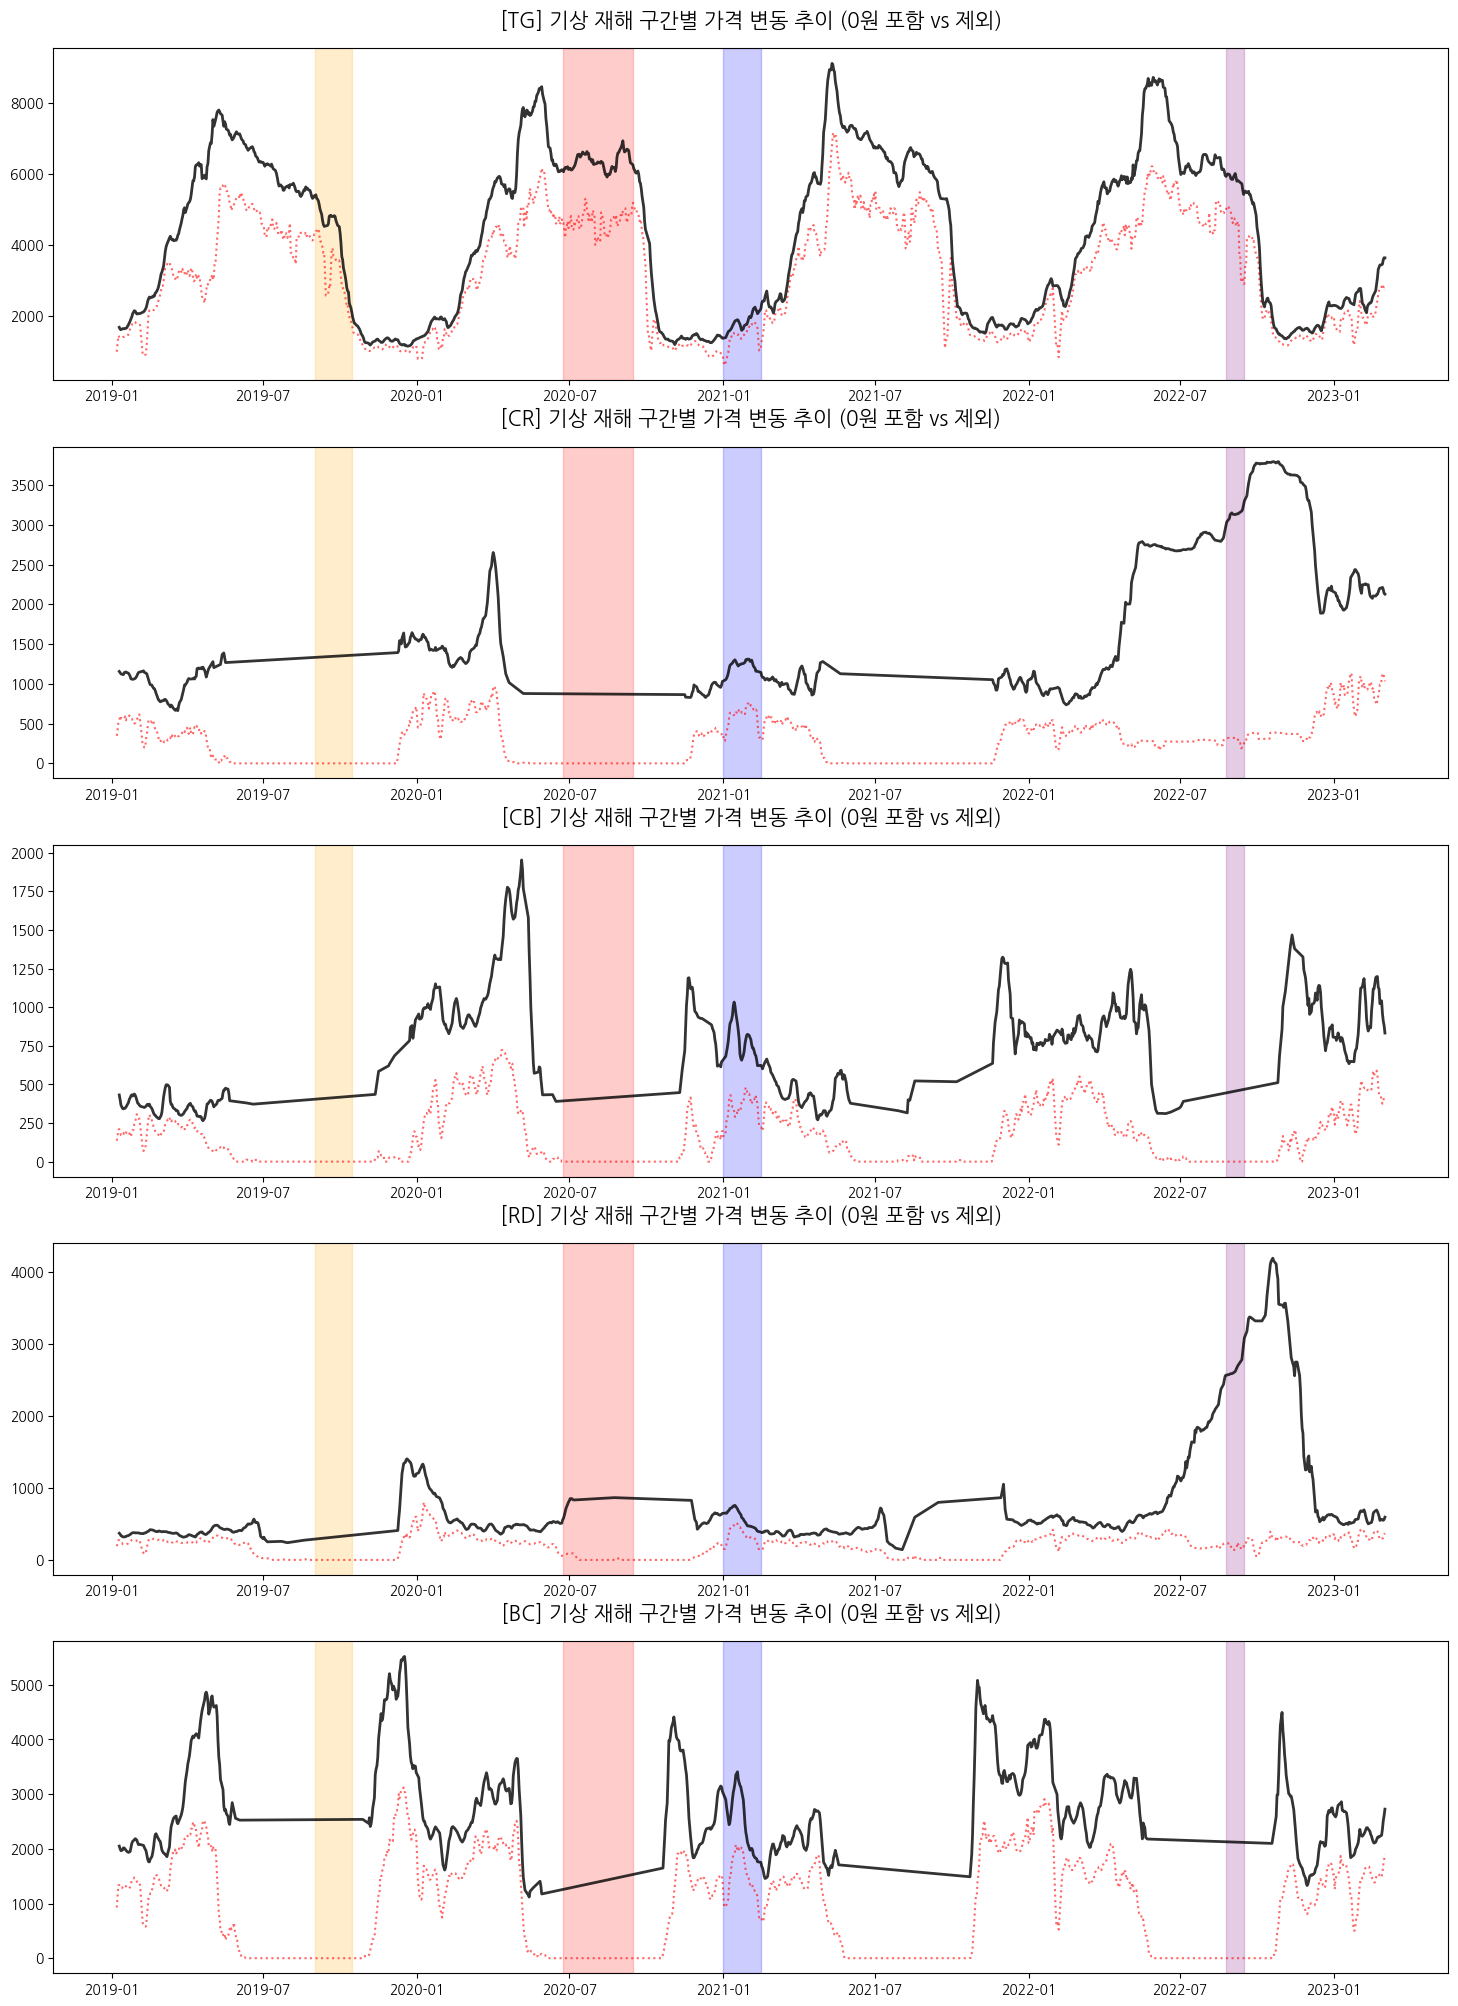

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 로드 및 날짜 설정
train = pd.read_csv('train.csv')
train['timestamp'] = pd.to_datetime(train['timestamp'])
target_col = 'price(원/kg)'  # 만약 앞에서 컬럼명을 바꿨다면 'price'로 수정하세요!

# 2. 분석에 활용할 기상 이변 기간 정의
weather_events = [
    {'name': '2019 가을 태풍(링링 등)', 'start': '2019-09-01', 'end': '2019-10-15', 'color': 'orange'},
    {'name': '2020 최장 장마/태풍', 'start': '2020-06-24', 'end': '2020-09-15', 'color': 'red'},
    {'name': '2021 연초 한파/폭설', 'start': '2021-01-01', 'end': '2021-02-15', 'color': 'blue'},
    {'name': '2022 태풍 힌남노', 'start': '2022-08-25', 'end': '2022-09-15', 'color': 'purple'}
]

# 3. 시각화 (품목별 가격 추이 + 기상 이변 구간 강조)
items = train['item'].unique()

# [수정포인트 1] sharex=False 로 변경하여 모든 그래프에 X축이 생기도록 함
fig, axes = plt.subplots(len(items), 1, figsize=(18, 5 * len(items)), sharex=False)

for i, item in enumerate(items):
    # A. 0원 포함 데이터 (빨간 점선용) - 해당 일자의 전체 평균
    df_all = train[train['item'] == item]
    daily_mean_all = df_all.groupby('timestamp')[target_col].mean()
    rolling_all = daily_mean_all.rolling(window=7).mean()
    
    # B. 0원 제외 데이터 (검은 실선용) - 실제 거래가 일어난 시세 평균
    df_real = train[(train['item'] == item) & (train[target_col] > 0)]
    daily_mean_real = df_real.groupby('timestamp')[target_col].mean()
    rolling_real = daily_mean_real.rolling(window=7).mean()
    
    # 그래프 그리기
    axes[i].plot(rolling_all.index, rolling_all.values, label='0원 포함 전체 (시장 체감가)', 
                 color='red', alpha=0.6, linestyle=':')
    
    axes[i].plot(rolling_real.index, rolling_real.values, label='0원 제외 (실제 낙찰가)', 
                 color='black', alpha=0.8, linewidth=2)
    
    # 기상 이변 구간 배경색(Shading) 입히기
    for event in weather_events:
        axes[i].axvspan(pd.to_datetime(event['start']), pd.to_datetime(event['end']), 
                        color=event['color'], alpha=0.2, label=event['name'])
    
    axes[i].set_title(f'[{item}] 기상 재해 구간별 가격 변동 추이 (0원 포함 vs 제외)', fontsize=15, pad=15)
    axes

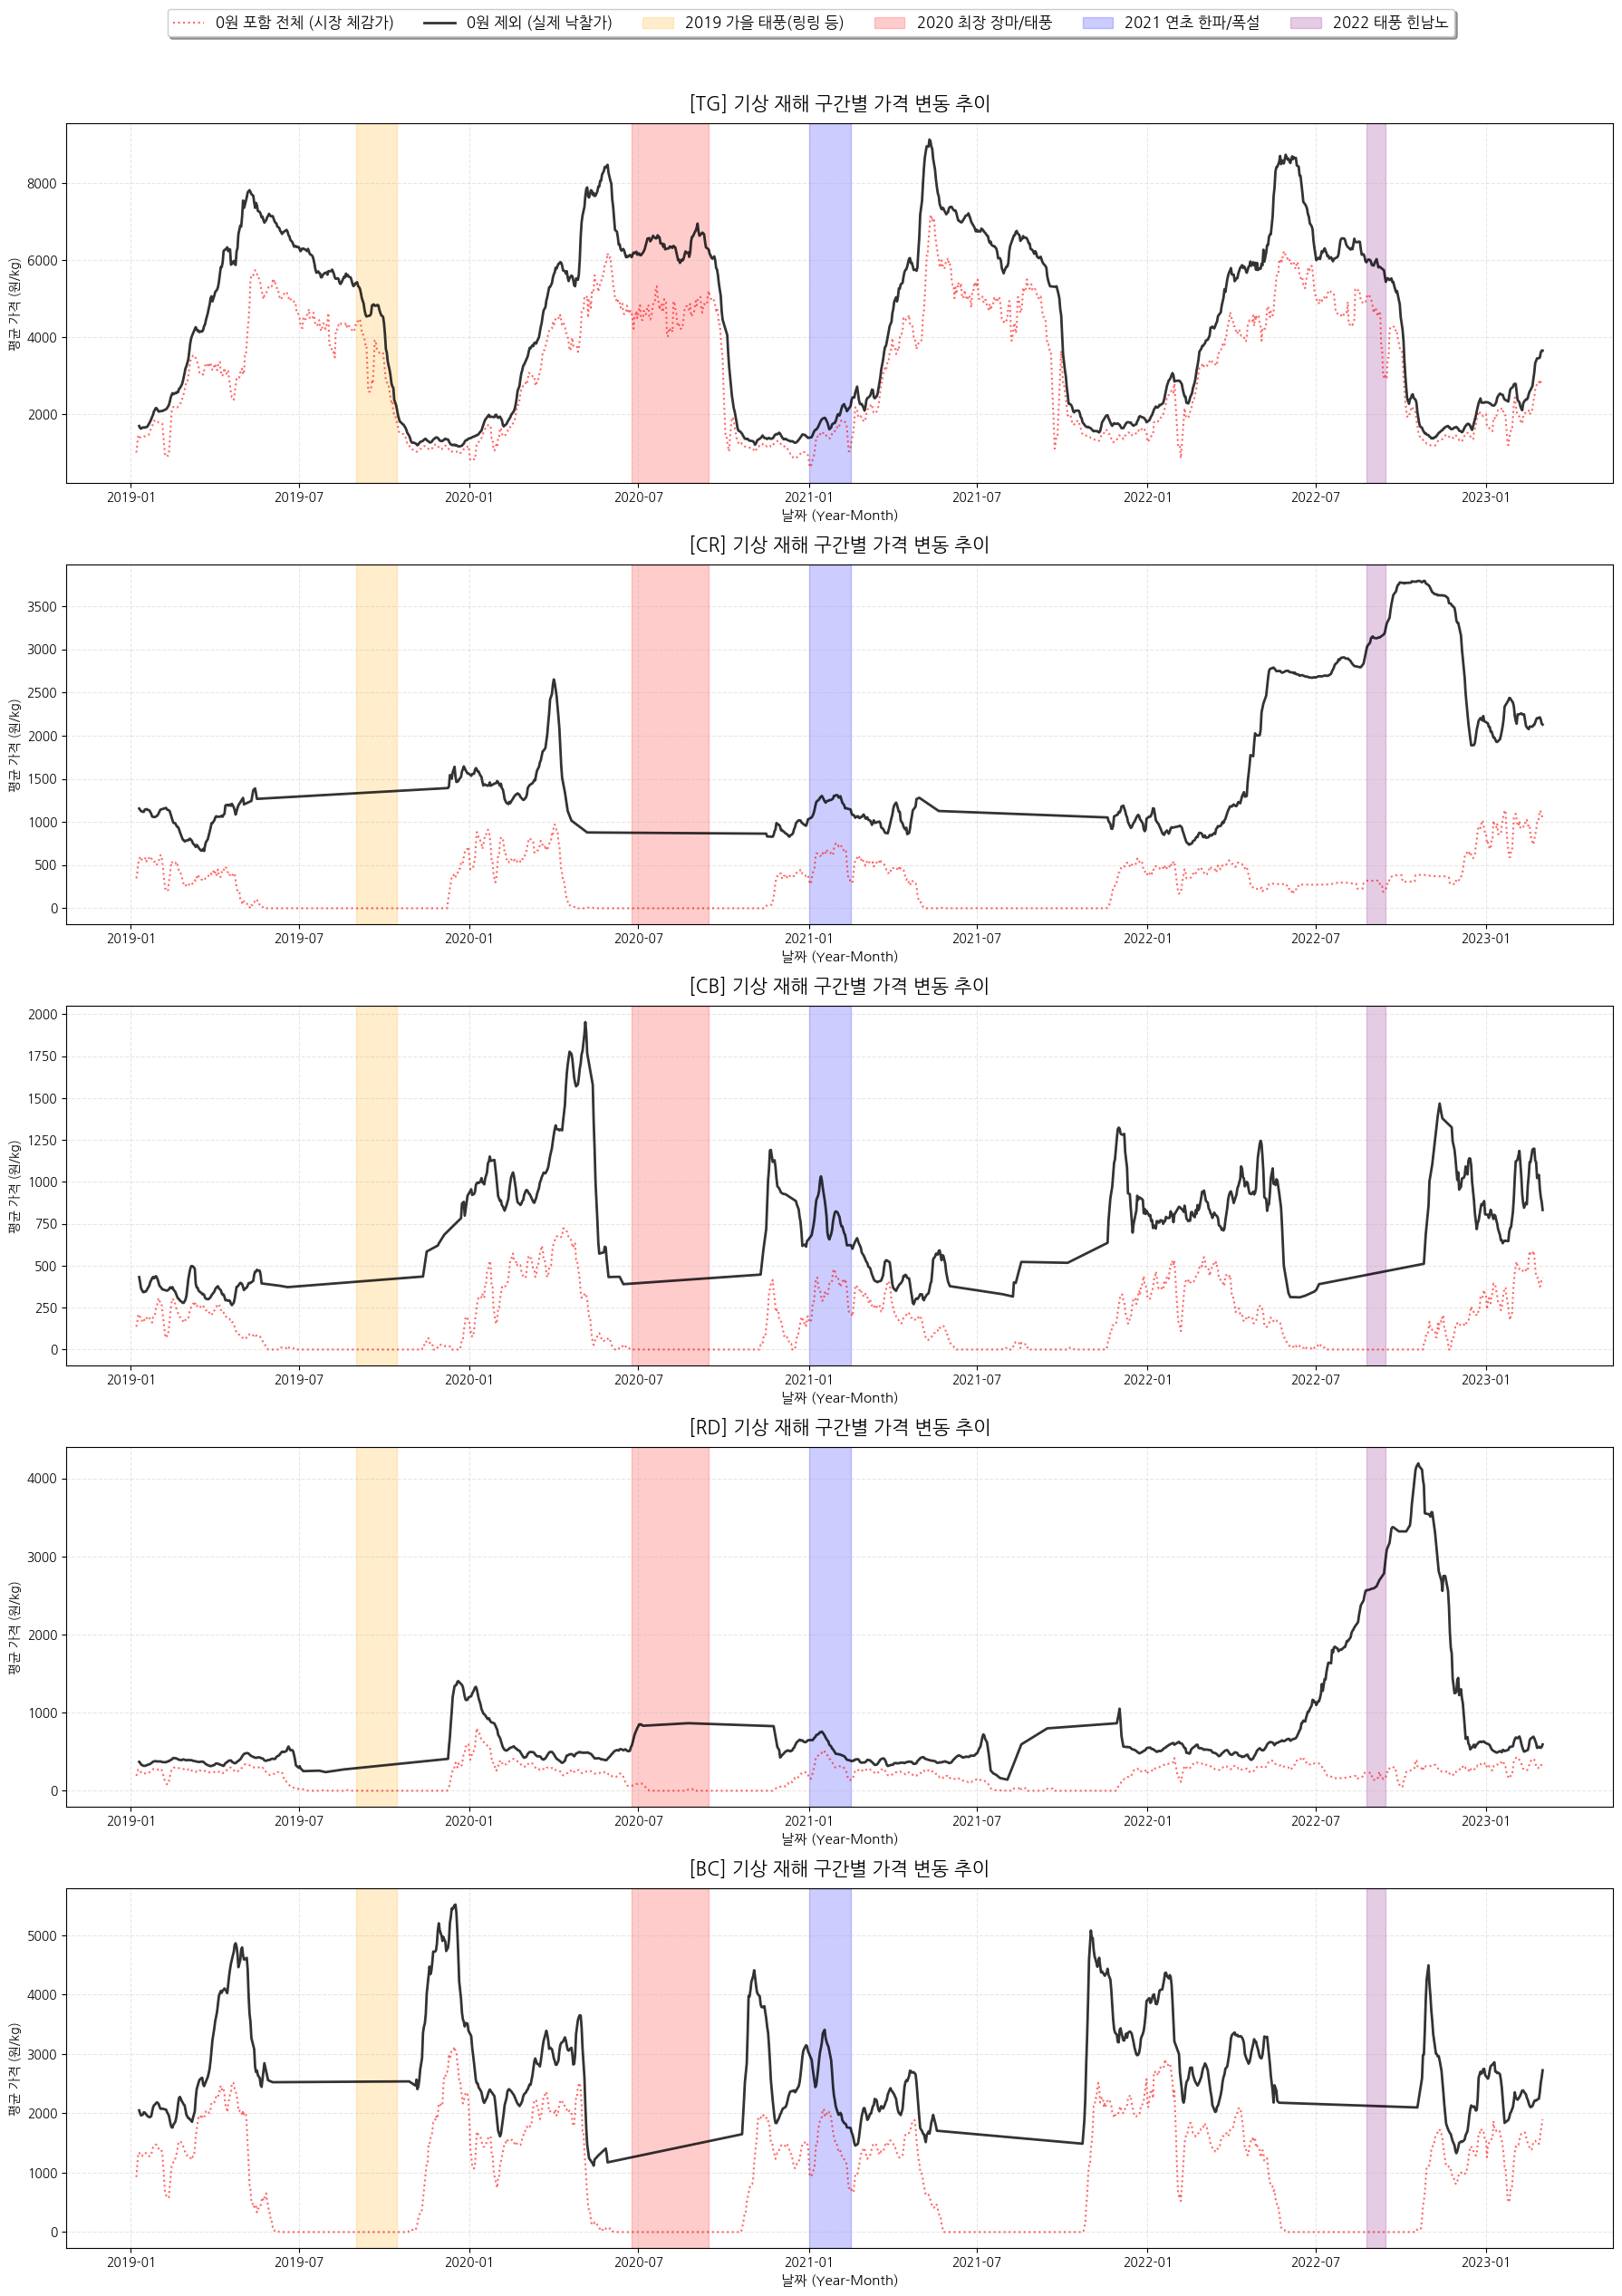

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 로드 및 날짜 설정
train = pd.read_csv('train.csv')
train['timestamp'] = pd.to_datetime(train['timestamp'])
target_col = 'price(원/kg)'  # 만약 앞에서 컬럼명을 바꿨다면 'price'로 수정하세요!

# 2. 분석에 활용할 기상 이변 기간 정의
weather_events = [
    {'name': '2019 가을 태풍(링링 등)', 'start': '2019-09-01', 'end': '2019-10-15', 'color': 'orange'},
    {'name': '2020 최장 장마/태풍', 'start': '2020-06-24', 'end': '2020-09-15', 'color': 'red'},
    {'name': '2021 연초 한파/폭설', 'start': '2021-01-01', 'end': '2021-02-15', 'color': 'blue'},
    {'name': '2022 태풍 힌남노', 'start': '2022-08-25', 'end': '2022-09-15', 'color': 'purple'}
]

# 3. 시각화 (품목별 가격 추이 + 기상 이변 구간 강조)
items = train['item'].unique()

# sharex=False 로 각 그래프마다 X축 살리기
fig, axes = plt.subplots(len(items), 1, figsize=(18, 5 * len(items)), sharex=False)

for i, item in enumerate(items):
    # A. 0원 포함 데이터 (빨간 점선용) - 해당 일자의 전체 평균
    df_all = train[train['item'] == item]
    daily_mean_all = df_all.groupby('timestamp')[target_col].mean()
    rolling_all = daily_mean_all.rolling(window=7).mean()
    
    # B. 0원 제외 데이터 (검은 실선용) - 실제 거래가 일어난 시세 평균
    df_real = train[(train['item'] == item) & (train[target_col] > 0)]
    daily_mean_real = df_real.groupby('timestamp')[target_col].mean()
    rolling_real = daily_mean_real.rolling(window=7).mean()
    
    # 그래프 그리기
    axes[i].plot(rolling_all.index, rolling_all.values, label='0원 포함 전체 (시장 체감가)', 
                 color='red', alpha=0.6, linestyle=':')
    
    axes[i].plot(rolling_real.index, rolling_real.values, label='0원 제외 (실제 낙찰가)', 
                 color='black', alpha=0.8, linewidth=2)
    
    # 기상 이변 구간 배경색(Shading) 입히기
    for event in weather_events:
        axes[i].axvspan(pd.to_datetime(event['start']), pd.to_datetime(event['end']), 
                        color=event['color'], alpha=0.2, label=event['name'])
    
    axes[i].set_title(f'[{item}] 기상 재해 구간별 가격 변동 추이', fontsize=15, pad=10)
    axes[i].set_ylabel('평균 가격 (원/kg)')
    
    # 각 그래프마다 X축 라벨(날짜) 명시
    axes[i].set_xlabel('날짜 (Year-Month)', fontsize=11) 
    axes[i].grid(True, alpha=0.3, linestyle='--')

# -------------------------------------------------------------
# [수정포인트] 개별 범례를 없애고, 맨 위에 '통합 범례' 1개만 생성
# -------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels() # 첫 번째 그래프의 범례 정보만 추출
by_label = dict(zip(labels, handles)) # 중복 제거

# 전체 피규어(fig)의 최상단 중앙에 가로로 넓게 범례 배치 (ncol=6 으로 한 줄에 나열)
fig.legend(by_label.values(), by_label.keys(), loc='upper center', 
           bbox_to_anchor=(0.5, 1.015), ncol=6, fontsize=12, frameon=True, shadow=True)

# 통합 범례가 들어갈 상단 공간(rect)을 살짝 비워두고 레이아웃 조정
plt.tight_layout(rect=[0, 0, 1, 0.98]) 
plt.show()